# Analyzing coherent structures in flows displaying transonic buffets using DMD #

In [ ]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parents[1] / "src"))
import dmd_claude

import matplotlib.pyplot as plt
import matplotlib.tri as tri
from stl import mesh
import torch as pt
import numpy as np
from flowtorch import DATASETS
from flowtorch.data import CSVDataloader, mask_box

# increase plot resolution
plt.rcParams["figure.dpi"] = 160

# Data Loading and Preparation #

In [ ]:
# # # From OpenFOAM file directories
# # Loading data
# data = "/home/prashant/uni/ml-study/datasets/naca0012_buffet/surface/"
# loader = CSVDataloader.from_foam_surface(data, "total(p)_coeff_airfoil.raw")

# times = loader.write_times
# # print(type(times))
# # print(len(times))
# # print(times)

# fields = loader.field_names
# # print(type(fields))
# # print(len(fields))

# print(f"Number of available snapshots: {len(times)}")
# # print("First five write times:", times[:5])
# # print(f"Fields available at t={times[-1]}: ", fields[times[-1]])

# field = next(iter(fields.values()))[0]   # 
# # print(type(fields))
# # print(len(field))
# # print(field)

# snapshot = loader.load_snapshot(field, times[0])

# # print("Snapshot type:", type(snapshot))
# print("Snapshot shape:", snapshot.shape)
# print(snapshot)

# # load vertices and discard z-coordinate
# vertices = loader.vertices[:, :2]

Number of available snapshots: 800
Snapshot shape: torch.Size([10010])
tensor([ 0.9412,  0.9412,  0.8250,  ..., -0.4523, -0.4523, -0.4012])


In [ ]:
times = np.load("naca0012_buffet_times.npy")
# print(type(times))
# print(len(times))
# print(times)

fields = np.load("naca0012_buffet_fields.npy", allow_pickle=True).item()
# print(type(fields))
# print(fields.shape if hasattr(fields, "shape") else "no shape")
# print(fields.dtype)

print(f"Number of available snapshots: {len(times)}")
# print("First five write times:", times[:5])
# print(f"Fields available at t={times[-1]}: ", fields[times[-1]])

field = next(iter(fields.values()))[0]   # 
# # print(type(fields))
# # print(len(field))
# # print(field)

snapshot = pt.tensor(np.load("naca0012_buffet_snapshot.npy"))

print("Snapshot type:", type(snapshot))
print("Snapshot shape:", snapshot.shape)
print(snapshot)

# # load vertices and discard z-coordinate
vertices = pt.tensor(np.load("naca0012_buffet_vertices.npy"))
# print(type(vertices))
# print(len(vertices))
# print(vertices)

Number of available snapshots: 800
Snapshot type: <class 'torch.Tensor'>
Snapshot shape: torch.Size([10010])
tensor([ 0.9412,  0.9412,  0.8250,  ..., -0.4523, -0.4523, -0.4012])
<class 'torch.Tensor'>
10010


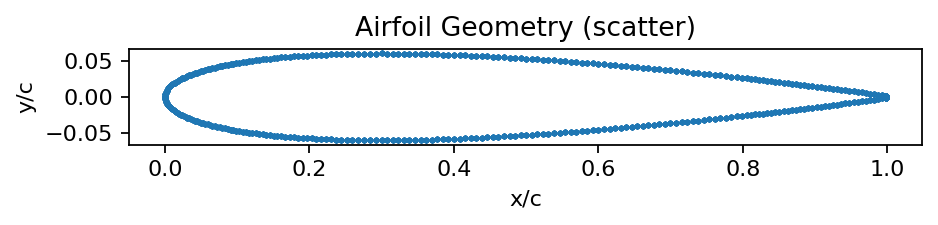

In [15]:
# Normalize vertices with chord length c=0.60105
c = 0.60105 # chord length for normalization
x = vertices[:, 0]
y = vertices[:, 1]

normalized_vertices = pt.zeros_like(vertices)
# print(type(normalized_vertices))

normalized_vertices[:, 0] = (x - x.min()) / c
normalized_vertices[:, 1] = y / c

# Plotting x and y
plt.figure()
plt.scatter(normalized_vertices[:, 0], normalized_vertices[:, 1], s=2)
plt.gca().set_aspect('equal')
plt.xlabel("x/c")
plt.ylabel("y/c")
plt.title("Airfoil Geometry (scatter)")
plt.show()


In [16]:
#  Boolean mask
mask = mask_box(normalized_vertices, lower=[0.0, 0.0], upper=[1.0, 0.05])
# print(type(mask))
# print(mask)

x = pt.masked_select(normalized_vertices[:, 0], mask)
y = pt.masked_select(normalized_vertices[:, 1], mask)

n_points = mask.sum().item()
print("No of points",n_points)

# First and last write_times
print("First write time: ", times[0])
print("Last write time: ", times[-1])

# Time-step
time_step = float(times[1]) - float(times[0])
print(time_step)

# New time list
window_times = [t for t in times if float(t) >= 0.0326 and float(t) <= 0.1015]
# print(window_times[-1])
# print(type(window_times))
print(len(window_times))

num_times = [float(t) for t in window_times]
# print(num_times[-1])
# print(type(num_times))
# print(len(num_times))

No of points 3484
First write time:  0.03
Last write time:  0.1099
9.99999999999994e-05
690


In [ ]:
# # Initialize an empty data matrix
# data_matrix = pt.zeros((n_points, len(window_times)))
# # V = pt.zeros_like(U)
# # print(data_matrix.shape)
# # print(data_matrix)
# # print(np.size(window_times))


# # Assemble the data matrix
# for i, t in enumerate(window_times):
#     tempMatrix = loader.load_snapshot("total(p)_coeff", t)
#     data_matrix[:, i] = pt.masked_select(tempMatrix[0], mask)
#     # V[:, i] = pt.masked_select(Utemp[1], mask)

# # print(data_matrix.shape)
# # print(data_matrix)

In [17]:
# Using pre-made data-matrix
data_matrix = pt.tensor(np.load("naca0012_buffet_data-matrix.npy"))
print(type(data_matrix))
print(data_matrix.shape)

<class 'torch.Tensor'>
torch.Size([3484, 690])


Text(0.5, 1.0, '$v$')

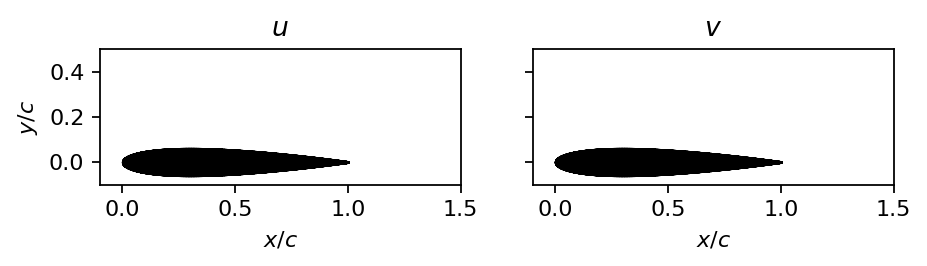

In [ ]:
# naca_data = "/home/prashant/uni/ml-study/datasets/naca0012_buffet/"

# def add_naca0012_patch(axis, scale=1.0):
#     x_up = naca_stl.x[naca_stl.y > 0] * scale
#     y_up = naca_stl.y[naca_stl.y > 0] * scale
#     x_low = naca_stl.x[naca_stl.y < 0] * scale
#     y_low = naca_stl.y[naca_stl.y < 0] * scale
#     axis.fill_between(x_up, 0.0, y_up, color="k", zorder=5)
#     axis.fill_between(x_low, y_low, 0.0, color="k", zorder=5)
    
# naca_stl = mesh.Mesh.from_file(naca_data + "naca0012.stl")

# fig, axarr = plt.subplots(1, 2, sharex=True, sharey=True)
# axarr[0].tricontourf(x, y, data_matrix.mean(dim=1), levels=14, cmap="jet")
# axarr[1].tricontourf(x, y, data_matrix.var(dim=1), levels=14, cmap="jet")

# for ax in axarr.flatten():
#     add_naca0012_patch(ax)
#     ax.set_aspect("equal", 'box')
#     ax.set_xlim(-0.1, 1.5)
#     ax.set_ylim(-0.1, 0.5)

# axarr[0].set_xlabel(r"$x/c$")
# axarr[1].set_xlabel(r"$x/c$")
# axarr[0].set_ylabel(r"$y/c$")
# axarr[0].set_title(r"$u$")
# axarr[1].set_title(r"$v$")

In [7]:
# naca_data = "/home/prashant/uni/ml-study/datasets/naca0012_buffet/"
# xa = pt.load(naca_data + "x_masked_3D_ref0_lecture.pt")
# ya = pt.load(naca_data + "y_masked_3D_ref0_lecture.pt")
# vol = pt.load(naca_data + "vol_masked_3D_ref0_lecture.pt")
# Uxy = pt.load(naca_data + "U_masked_3D_ref0_lecture.pt")
# # print(xa.shape)
# # print(ya.shape)
# # print(vol.shape)
# print(Uxy[:5, :, :5])

# DMD #

In [45]:
# a = pt.zeros([6,4])
# a

In [18]:
# data_matrix -= data_matrix.mean(dim=1).unsqueeze(-1)
# U, s, VH = pt.linalg.svd(data_matrix, full_matrices=False)
result = dmd_claude.compute_dmd(data_matrix, delta_t=time_step)


[2026-05-05 14:45:25] INFO     Input OK — shape: (3484, 690), Δt=0.0001 s, rank=689, mean_center=True
[2026-05-05 14:45:25] INFO     Computing truncated SVD (rank=689) …
[2026-05-05 14:45:26] INFO     Building reduced linear operator …
[2026-05-05 14:45:26] INFO     Computing eigendecomposition of reduced operator …
[2026-05-05 14:45:26] INFO     Reconstructing full-space DMD modes …
[2026-05-05 14:45:26] INFO     Positive-frequency modes: 352 / 689
[2026-05-05 14:45:26] INFO     Computing mode amplitudes from initial condition …
[2026-05-05 14:45:27] INFO     DMD computation complete.


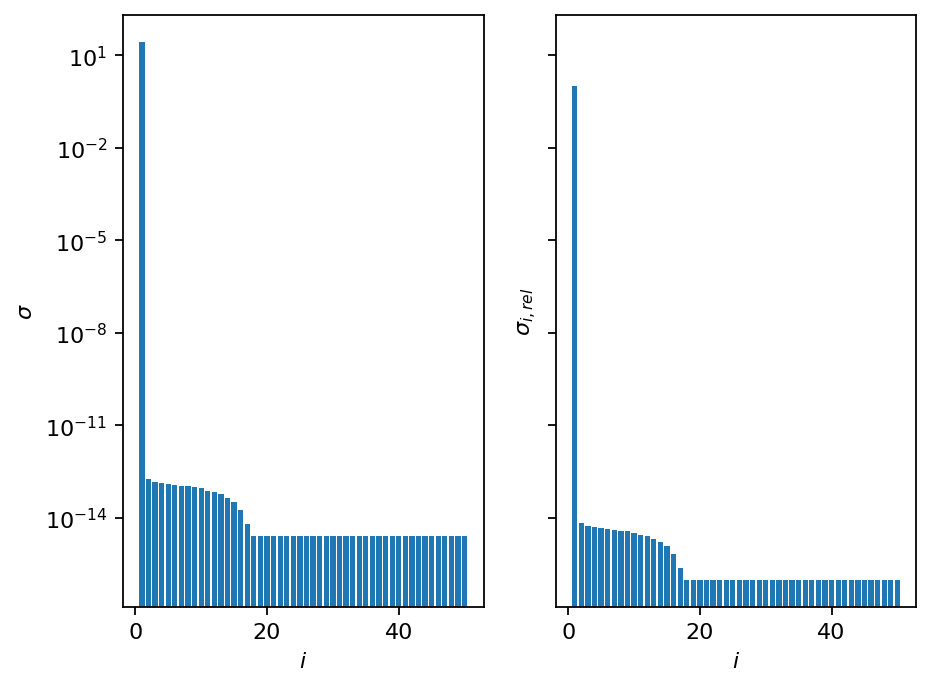

In [19]:
# Number of modes to plot
# Plotting first 50 modes
n_modes = min(50, len(result.singular_values))
# Mode indices
modes = np.arange(1, n_modes + 1)

# Normalized singular values
s_rel = [si/result.singular_values.sum().item() for si in result.singular_values]

fig, axarr = plt.subplots(1, 2, sharex=True, sharey=True)
axarr[0].bar(modes, result.singular_values[:n_modes])
axarr[1].bar(modes, s_rel[:n_modes])

axarr[0].set_xlabel(r"$i$")
axarr[1].set_xlabel(r"$i$")
axarr[0].set_ylabel(r"$\sigma$")
axarr[1].set_ylabel(r"$\sigma_{i,rel}$")
axarr[0].set_yscale("log")
axarr[1].set_yscale("log")

In [20]:
# Every column except the last column
X = data_matrix[:, :-1].clone()
# print(X.shape)

# Every column starting from the second column
X_prime = data_matrix[:, 1:].clone()
# print(X_prime.shape)

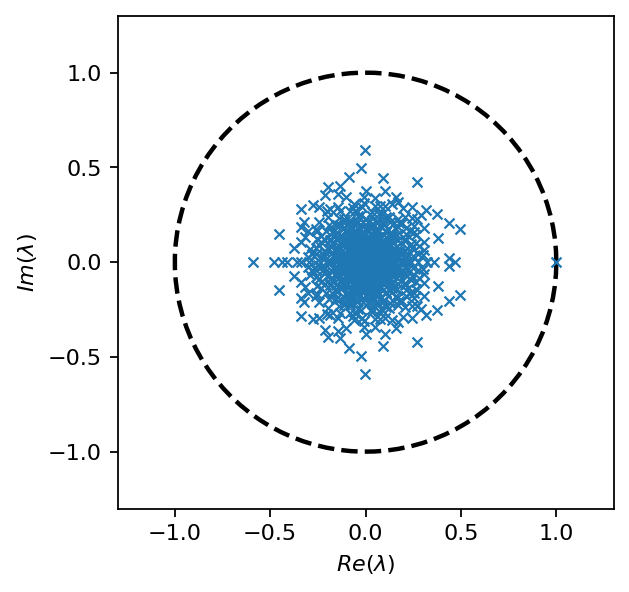

In [21]:
U, s, Vh = pt.linalg.svd(X, full_matrices=False)
V = Vh.T
Uh = U.T
# print(U.shape)
# print(Vh.shape)
# print(s.shape)

# Calculate reduced linear operator
tol = 1e-10
s_inv = pt.diag(1.0/(s + tol))
A_tilde = Uh @ X_prime @ V @ s_inv

# Compute the eigen decomposition of the reduced linear operator
eigenvals, eigenvec = pt.linalg.eig(A_tilde)

# Reconstruct the modes of the full linear operator
phi = (X_prime @ V @ s_inv).to(pt.cfloat) @ eigenvec

# Compute the complex conjugate transpose
phi_cct = phi.conj().T

# Plotting
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
t = pt.linspace(0, 2 * np.pi, 100)
ax.plot(pt.cos(t), pt.sin(t), ls="--", color="k", lw=2)
ax.scatter(eigenvals.real, eigenvals.imag, marker="x", lw=1, s=20, zorder=7)
ax.set_xlim(-1.3, 1.3)
ax.set_ylim(-1.3, 1.3)
ax.set_xlabel(r"$Re(\lambda)$")
ax.set_ylabel(r"$Im(\lambda)$")
plt.show()

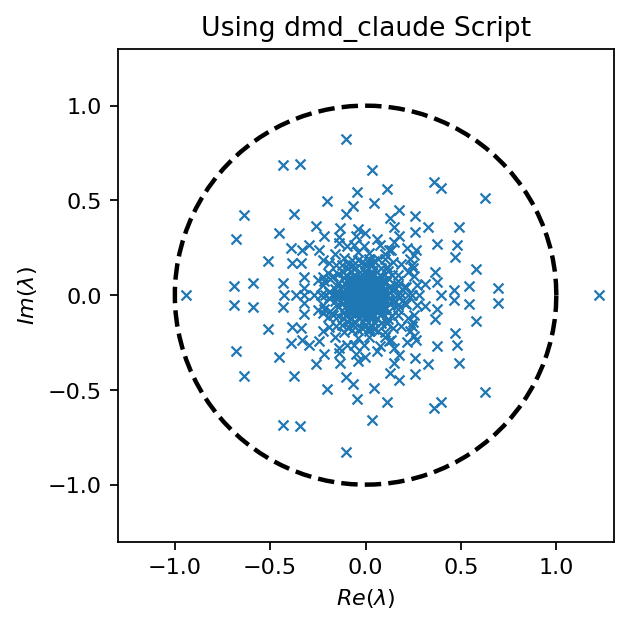

In [22]:
# Using dmd_claude
# Plotting
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
t = pt.linspace(0, 2 * np.pi, 100)
ax.plot(pt.cos(t), pt.sin(t), ls="--", color="k", lw=2)
ax.scatter(result.eigenvalues.real, result.eigenvalues.imag, marker="x", lw=1, s=20, zorder=7)
ax.set_xlim(-1.3, 1.3)
ax.set_ylim(-1.3, 1.3)
ax.set_xlabel(r"$Re(\lambda)$")
ax.set_ylabel(r"$Im(\lambda)$")
ax.set_title("Using dmd_claude Script")
plt.show()

In [23]:
print(eigenvals[:10])
print(eigenvals.abs().mean())

tensor([ 0.4701+1.8480j,  0.4701-1.8480j,  0.9978+0.0000j, -0.5912+0.0000j,
        -0.0021+0.5922j, -0.0021-0.5922j,  0.4974+0.1739j,  0.4974-0.1739j,
         0.2672+0.4211j,  0.2672-0.4211j])
tensor(0.1979)


In [24]:
# Angular frequencies - omega_i = log(lambda_i)/delta_t
omega = pt.log(eigenvals) / time_step

# Frequency
freq = omega.imag / (2.0*np.pi)
freq_i_pos = (freq > 0).nonzero().flatten()

# Mode Amplitudes
b = pt.linalg.pinv(phi) @ X[:, 0].to(phi.dtype)
amplitude = b.abs()

In [25]:
# # print(freq[freq_i_pos].numpy())
# print(type(freq[freq_i_pos].numpy()))
# print(freq[freq_i_pos].numpy().size)

# # print(amplitude[freq_i_pos].numpy())
# print(type(amplitude[freq_i_pos].numpy()))
# print(amplitude[freq_i_pos].numpy().size)

# print(pt.sort(amplitude, descending=True).values[:10])

# unique_freq = pt.unique(freq[freq_i_pos].round(decimals=2))
# print(len(unique_freq))

print(amplitude.min(), amplitude.max())
print(amplitude[:20])

tensor(0.0052) tensor(2.4785)
tensor([2.4785, 2.4785, 1.2973, 0.7663, 0.7695, 0.7695, 0.6854, 0.6854, 0.6487,
        0.6487, 0.6308, 0.6308, 0.6471, 0.6471, 0.6228, 0.6228, 0.6209, 0.5727,
        0.5727, 0.5869])


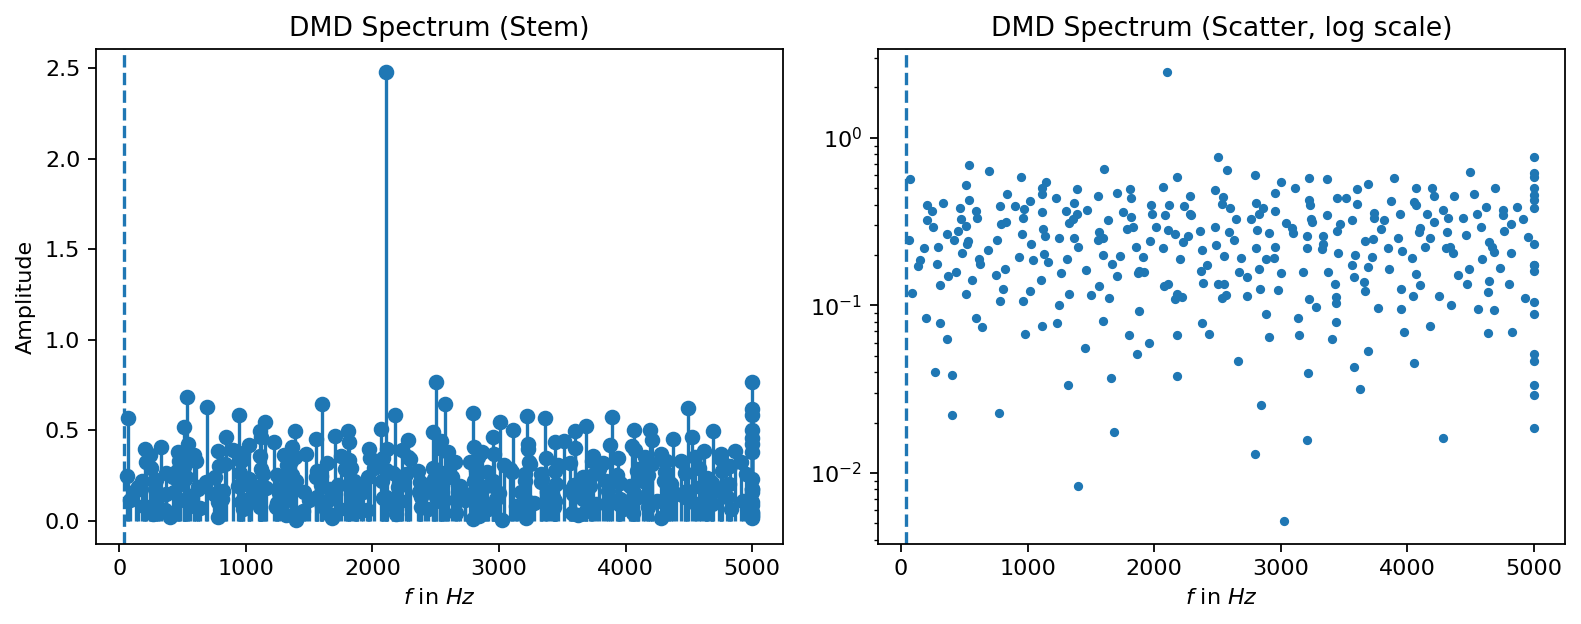

In [26]:
fig, axarr = plt.subplots(1, 2, figsize=(10, 4), sharex=True)

# Stem plot (dominant modes view)
axarr[0].stem(
    freq[freq_i_pos].numpy(),
    amplitude[freq_i_pos].numpy(),
    basefmt="None"
)
axarr[0].set_title("DMD Spectrum (Stem)")
axarr[0].set_xlabel(r"$f$ in $Hz$")
axarr[0].set_ylabel("Amplitude")

# Scatter plot (full spectrum view)
axarr[1].scatter(
    freq[freq_i_pos].numpy(),
    amplitude[freq_i_pos].numpy(),
    s=10
)
axarr[1].set_yscale("log")
axarr[1].set_title("DMD Spectrum (Scatter, log scale)")
axarr[1].set_xlabel(r"$f$ in $Hz$")

# Optional reference line
for ax in axarr:
    ax.axvline(38, ls="--")

plt.tight_layout()
plt.show()

Using dmd_claude script ...


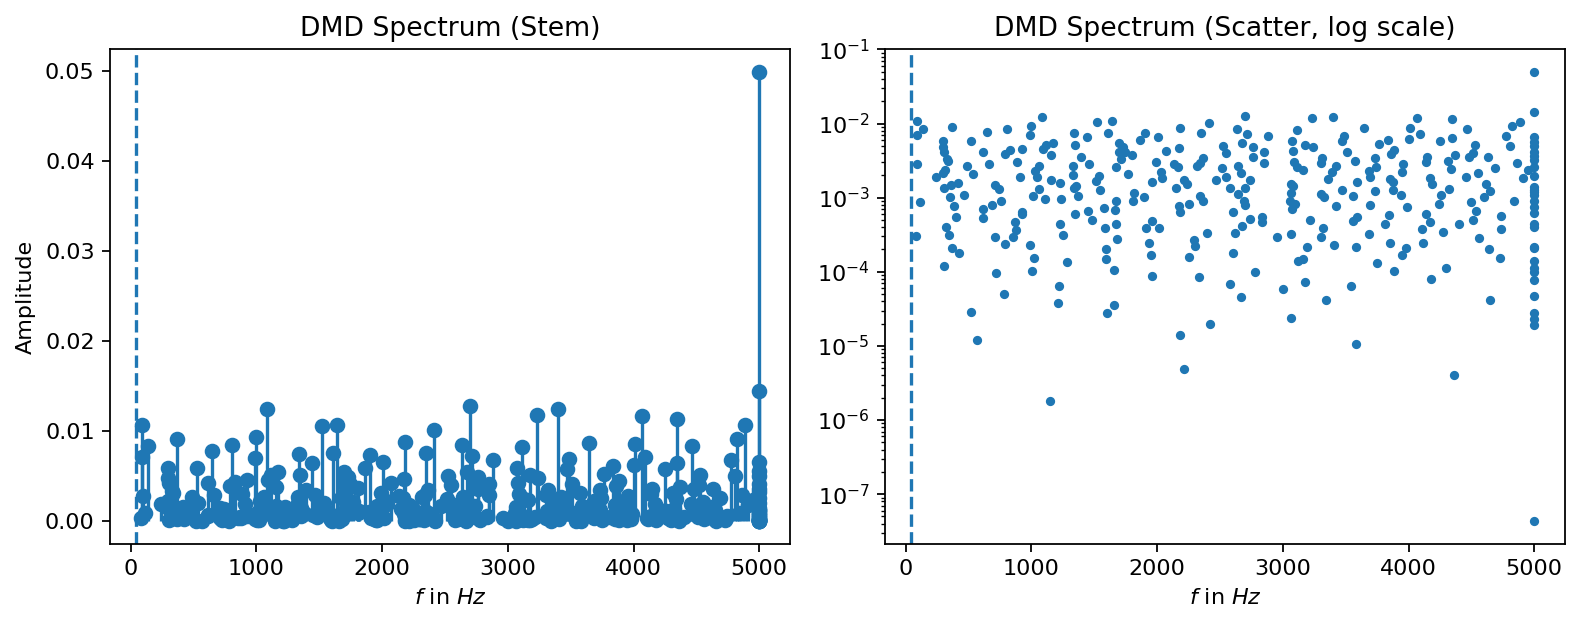

In [27]:
print("Using dmd_claude script ...")

fig, axarr = plt.subplots(1, 2, figsize=(10, 4), sharex=True)

# Stem plot (dominant modes view)
axarr[0].stem(
    result.frequencies[result.positive_freq_indices].numpy(),
    result.amplitudes[result.positive_freq_indices].numpy(),
    basefmt="None"
)
axarr[0].set_title("DMD Spectrum (Stem)")
axarr[0].set_xlabel(r"$f$ in $Hz$")
axarr[0].set_ylabel("Amplitude")

# Scatter plot (full spectrum view)
axarr[1].scatter(
    result.frequencies[result.positive_freq_indices].numpy(),
    result.amplitudes[result.positive_freq_indices].numpy(),
    s=10
)
axarr[1].set_yscale("log")
axarr[1].set_title("DMD Spectrum (Scatter, log scale)")
axarr[1].set_xlabel(r"$f$ in $Hz$")

# Optional reference line
for ax in axarr:
    ax.axvline(38, ls="--")

plt.tight_layout()
plt.show()